<a href="https://colab.research.google.com/github/DABMASTER-Brought-me-into-this/ZeroToHeroColabCollection/blob/main/recall_makemore.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
# Retrieving Text From File
words = open("data.txt").read().split()
# Getting All Characters
chars = sorted(list(set(''.join(words))))
# Assigning all Character n numbers a number n a letter
stoi = {char: ord(char) - 96 for char in chars}
stoi['.'] = 0
itos = {val: key for key, val in stoi.items()}

In [ ]:
# Creating a Tensor to Store this
N = torch.zeros((27,27), dtype = torch.int32)

for word in words:
  chs = ['.'] + list(word) + ['.']
  for x in range(len(chs) - 1):
    N[stoi[chs[x]], stoi[chs[x+1]]] += 1

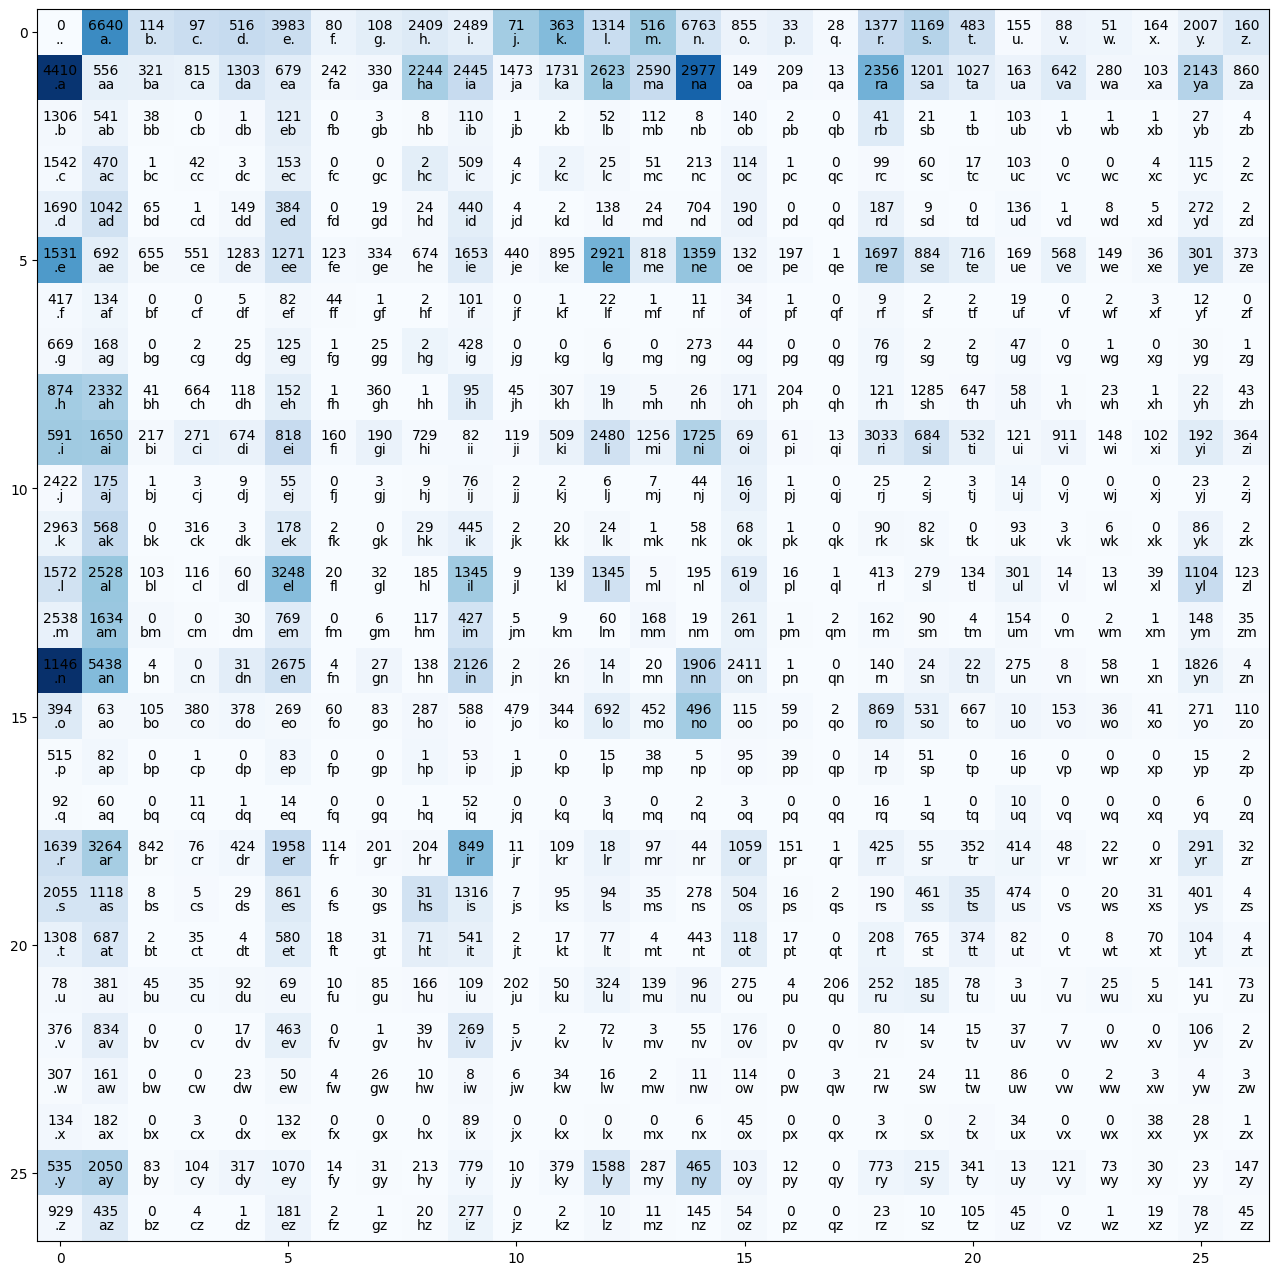

In [ ]:
# Showing The Data in A Nice Manner
plt.figure(figsize=(16,16))
plt.imshow(N, cmap="Blues")
for i in range(N.shape[0]):
  for j in range(N.shape[1]):
    chstr = itos[i] + itos[j]
    plt.text(i, j, chstr, ha = "center", va = "top",  color = "black")
    plt.text(i, j, N[i,j].item(), ha = "center", va = "bottom",  color = "black")

In [ ]:
# Getting Probability Plot + Smoothing It
P = (N+1).float()/(N+1).float().sum(1, keepdim = True)

In [ ]:
log_likelihood = 0.0
n = 0

for word in words[:3]:
  chs = ['.'] + list(word) + ['.']
  for x in range(len(chs) - 1):
    ix1 = stoi[chs[x]]
    ix2 = stoi[chs[x+1]]
    logprob = torch.log(P[ix1, ix2])
    log_likelihood += logprob
    print(f"{itos[ix1] + itos[ix2]}: {logprob}")
    n += 1

nll = -log_likelihood/n
nll

.e: -3.0410351753234863
em: -3.2793476581573486
mm: -3.6753265857696533
ma: -0.9454260468482971
a.: -1.6305063962936401
.o: -4.396478652954102
ol: -2.5525903701782227
li: -1.7293236255645752
iv: -4.184478759765625
vi: -1.0476267337799072
ia: -1.9806911945343018
a.: -1.6305063962936401
.a: -1.983507752418518
av: -3.704092502593994
va: -1.3971220254898071
a.: -1.6305063962936401


tensor(2.4255)